# Model Training — Telco Customer Churn

Loads the cleaned dataset from `EDA_Customer_Churn.ipynb`, trains and compares several
classification models, tunes the best one, and saves the final model + preprocessor
for deployment.


## 1. Load the Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Telco_Customer_Churn_clean.csv')
print(df.shape)
df.head()


(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. Train-Test Split

Stratify on `Churn` since the classes are imbalanced (~73% / ~27%) — this keeps the
same class ratio in both the train and test sets.


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '  Test:', X_test.shape)
print('Train churn rate:', y_train.mean().round(3), '  Test churn rate:', y_test.mean().round(3))


Train: (5634, 19)   Test: (1409, 19)
Train churn rate: 0.265   Test churn rate: 0.265


## 3. Identify Numerical and Categorical Features


In [3]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical ({len(numerical_features)}):", numerical_features)
print(f"Categorical ({len(categorical_features)}):", categorical_features)


Numerical (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\Mamtaam\AppData\Local\Temp\ipykernel_12048\2104236899.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()


## 4 & 5. Preprocessing Pipeline — Standard Scaling + One-Hot Encoding

Built as a single `ColumnTransformer` so it's fit only on the training data and applied
consistently to the test set (and later, to any new input from the Flask app) —
no leakage from test into train.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print('Transformed train shape:', X_train_transformed.shape)
print('Transformed test shape:', X_test_transformed.shape)


Transformed train shape: (5634, 45)
Transformed test shape: (1409, 45)


## 6. Feature Selection

Use `SelectKBest` (ANOVA F-value) on the transformed features to keep the most
informative ones and reduce noise from the one-hot expansion.


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Get feature names after one-hot encoding, for later interpretation
feature_names = preprocessor.get_feature_names_out()

k = min(25, X_train_transformed.shape[1])  
selector = SelectKBest(score_func=f_classif, k=6)

X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)

selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]

print(f"Selected {len(selected_features)} of {len(feature_names)} features:")
print(list(selected_features))


Selected 6 of 45 features:
['num__tenure', 'cat__InternetService_Fiber optic', 'cat__OnlineSecurity_No', 'cat__TechSupport_No', 'cat__Contract_Month-to-month', 'cat__PaymentMethod_Electronic check']


## 7. Feature Importance

Fit a quick Random Forest on the selected features purely to inspect importances —
this is diagnostic, separate from the final model comparison in the next step.


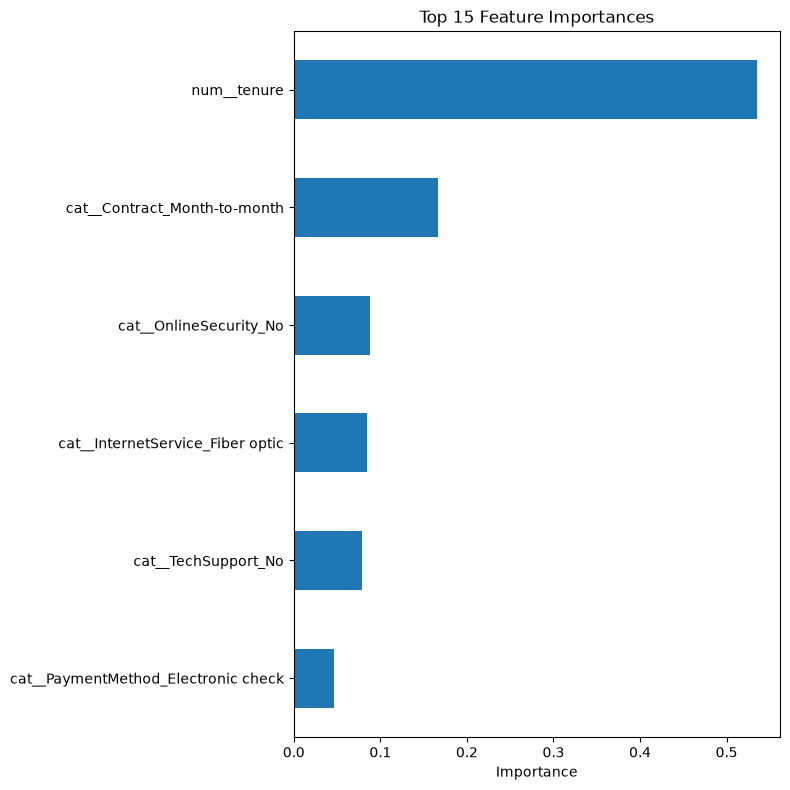

num__tenure                            0.534979
cat__Contract_Month-to-month           0.166824
cat__OnlineSecurity_No                 0.088231
cat__InternetService_Fiber optic       0.084025
cat__TechSupport_No                    0.079177
cat__PaymentMethod_Electronic check    0.046763
dtype: float64

In [7]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

rf_probe = RandomForestClassifier(n_estimators=200, random_state=42)
rf_probe.fit(X_train_selected, y_train)

importances = pd.Series(rf_probe.feature_importances_, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(15)


## 8. Train Multiple Models

Compare a spread of model families on the same selected features.


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: Gradient Boosting
Trained: XGBoost


## 9. Evaluate & Compare Models

Since the classes are imbalanced, accuracy alone is misleading — look at precision,
recall, F1, and ROC-AUC together, and pick the model that best fits the business goal
(for churn, missing an actual churner — low recall on class 1 — is usually the costlier mistake).


In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_selected)
    y_proba = model.predict_proba(X_test_selected)[:, 1] if hasattr(model, 'predict_proba') else None

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.799858,0.650327,0.532086,0.585294,0.837086
1,Logistic Regression,0.795600,0.635220,0.540107,0.583815,0.833408
2,XGBoost,0.781405,0.598802,0.534759,0.564972,0.812165
3,Random Forest,0.765791,0.559140,0.556150,0.557641,0.793198
4,Decision Tree,0.763662,0.558739,0.521390,0.539419,0.757711


In [10]:
# Confusion matrix + full report for the top model by F1
best_name_pre_tuning = results_df.iloc[0]['Model']
best_model_pre_tuning = trained_models[best_name_pre_tuning]

y_pred_best = best_model_pre_tuning.predict(X_test_selected)

print(f"Best model before tuning: {best_name_pre_tuning}\n")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Best model before tuning: Gradient Boosting

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[928 107]
 [175 199]]


## 10. Hyperparameter Tuning

Tune the best-performing model from the comparison above with `RandomizedSearchCV`.
The parameter grid below is written for `RandomForestClassifier` / `GradientBoostingClassifier` / `XGBoost` / `LogisticRegression`


In [11]:
from sklearn.model_selection import RandomizedSearchCV

print(f"Tuning: {best_name_pre_tuning}")

if best_name_pre_tuning in ['Random Forest', 'Gradient Boosting']:
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif best_name_pre_tuning == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.85, 1.0]
    }
else:  # Logistic Regression / Decision Tree fallback
    param_grid = {'C': [0.01, 0.1, 1, 10]} if best_name_pre_tuning == 'Logistic Regression' \
        else {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}

base_model = type(best_model_pre_tuning)(random_state=42) if 'random_state' in best_model_pre_tuning.get_params() else type(best_model_pre_tuning)()

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_selected, y_train)

print("Best params:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_.round(4))


Tuning: Gradient Boosting
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5}
Best CV F1: 0.5703


## 11. Select the Best-Performing Model

Compare the tuned model against the pre-tuning best on the held-out test set, and keep
whichever actually performs better on data it hasn't seen (tuning can occasionally
overfit to the CV folds).


In [12]:
tuned_model = random_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_selected)

tuned_f1 = f1_score(y_test, y_pred_tuned)
pre_tuning_f1 = results_df.iloc[0]['F1']

print(f"Pre-tuning F1: {pre_tuning_f1:.4f}")
print(f"Tuned F1:      {tuned_f1:.4f}")

final_model = tuned_model if tuned_f1 >= pre_tuning_f1 else best_model_pre_tuning
print(f"\nFinal model selected: {'Tuned ' + best_name_pre_tuning if tuned_f1 >= pre_tuning_f1 else best_name_pre_tuning}")

print("\nFinal test performance:")
y_pred_final = final_model.predict(X_test_selected)
print(classification_report(y_test, y_pred_final))


Pre-tuning F1: 0.5853
Tuned F1:      0.5644

Final model selected: Gradient Boosting

Final test performance:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## 12. Save the Final Model for Deployment

Save the fitted `preprocessor`, `selector`, and `final_model` — the prediction pipeline
in the Flask app needs all three, applied in this exact order:
raw input -> preprocessor.transform -> selector.transform -> model.predict


In [13]:
import dill
import os

os.makedirs('artifacts', exist_ok=True)

with open('artifacts/preprocessor.pkl', 'wb') as f:
    dill.dump(preprocessor, f)

with open('artifacts/selector.pkl', 'wb') as f:
    dill.dump(selector, f)

with open('artifacts/model.pkl', 'wb') as f:
    dill.dump(final_model, f)

print("Saved preprocessor.pkl, selector.pkl, and model.pkl to artifacts/")


Saved preprocessor.pkl, selector.pkl, and model.pkl to artifacts/


## Summary

- Loaded the cleaned dataset from the EDA notebook
- Stratified 80/20 train-test split
- Preprocessing: `StandardScaler` on numeric features, `OneHotEncoder` on categorical features, via a single `ColumnTransformer`
- Feature selection with `SelectKBest` to reduce the one-hot-expanded feature space
- Compared 5 model families (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost) on F1 (accuracy alone is misleading with class imbalance)
- Tuned the best pre-tuning model with `RandomizedSearchCV`
- Selected whichever of tuned/untuned scored higher on the held-out test set
- Saved `preprocessor.pkl`, `selector.pkl`, and `model.pkl` to `artifacts/` for the Flask app

**Note:** the Flask prediction pipeline (`predict_pipeline.py`) will need to apply
`selector.transform()` after `preprocessor.transform()` and before `model.predict()` —
this is a step your current pipeline code skips, which will need fixing when you wire
this new model in.
